<a href="https://colab.research.google.com/github/NEO18082005/housing-price-regression-analysis/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Task 1 — Data Loading & Exploration**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
df = pd.read_csv('Housing.csv')

 *Display the first 10 rows*

In [ ]:
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


*Check how many rows and columns are there*

In [ ]:
df.shape

(545, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


*Identify which column is the target (Price) and which are features*

In [ ]:
X = df.drop('price', axis=1)  # Features (everything except price)
y = df['price']               # Target (price only)

print(y.head(10))

0    13300000
1    12250000
2    12250000
3    12215000
4    11410000
5    10850000
6    10150000
7    10150000
8     9870000
9     9800000
Name: price, dtype: int64


In [ ]:
print(X.head(10))

    area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0   7420         4          2        3      yes        no       no   
1   8960         4          4        4      yes        no       no   
2   9960         3          2        2      yes        no      yes   
3   7500         4          2        2      yes        no      yes   
4   7420         4          1        2      yes       yes      yes   
5   7500         3          3        1      yes        no      yes   
6   8580         4          3        4      yes        no       no   
7  16200         5          3        2      yes        no       no   
8   8100         4          1        2      yes       yes      yes   
9   5750         3          2        4      yes       yes       no   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              n

 *Check for missing values in each column*

In [ ]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


**Task 2 — Data Cleaning**

*Handle missing values (fill or drop, whichever fits the column)*
*Remove duplicate rows, if any*

In [ ]:
# Check for duplicates
print(f"Duplicate rows found: {df.duplicated().sum()}")

# Remove duplicates
df = df.drop_duplicates()

# Check for missing values
print(f"Missing values:\n{df.isnull().sum()}")

# Note: If we find missing values, we would use:
# df = df.dropna()  # To Drops rows with missing data
# OR
# df['column_name'] = df['column_name'].fillna(value) # To Fills missing data

Duplicate rows found: 0
Missing values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


*Convert any categorical columns (e.g., yes/no fields) into numeric form using one-hot encoding*

In [ ]:
# List of binary columns
binary_vars = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

# Define a function to map 'yes' to 1 and 'no' to 0
def binary_map(x):
    return x.map({'yes': 1, 'no': 0})

# Apply the function to the binary columns
df[binary_vars] = df[binary_vars].apply(binary_map)

# For 'furnishingstatus', use get_dummies to create numeric columns
# We use drop_first=True to avoid multicollinearity
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True, dtype=int)

# Check the first few rows to ensure everything looks numeric now
print(df.head(10))

      price   area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000   7420         4          2        3         1          0   
1  12250000   8960         4          4        4         1          0   
2  12250000   9960         3          2        2         1          0   
3  12215000   7500         4          2        2         1          0   
4  11410000   7420         4          1        2         1          1   
5  10850000   7500         3          3        1         1          0   
6  10150000   8580         4          3        4         1          0   
7  10150000  16200         5          3        2         1          0   
8   9870000   8100         4          1        2         1          1   
9   9800000   5750         3          2        4         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3      

*Keep only the columns that are meaningful for predicting price*

There are no extra "ID" or "Name" columns that would be useless for our model.

Because every column serves a purpose, we don't need to drop any columns to complete this step. We can proceed with the entire dataset.

However, if we ever decide later that a specific feature (e.g., guestroom) is not improving our model's accuracy, here is how we would remove it using code:

In [ ]:
# If we decide to drop a specific, less-meaningful column, we use this:
# For example, if we wanted to remove 'guestroom':

df = df.drop(columns=['guestroom'])

# To verify which columns you have left:
print(df.columns.tolist())

['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']


**Task 3 — Model Building**

*Split the data into training and test sets (80/20)*

*Train a Linear Regression model to predict house price*

*Evaluate it using MAE, RMSE, and R² Score*

*Train a second model — Random Forest Regressor — and compare its performance to the Linear Regression model*

**1: Data Preparation**

In [117]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Reload and Clean
df = pd.read_csv('Housing.csv')
df.columns = df.columns.str.strip()

# Map binary columns
binary_vars = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_vars:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# Encode categorical
df = pd.get_dummies(df, columns=['furnishingstatus'], drop_first=True, dtype=int)

# Define X and y
X = df.drop('price', axis=1)
y = df['price']

print("Data is prepared and split. You are ready to train models.")

Data is prepared and split. You are ready to train models.


**2: Model Training & Evaluation**

In [114]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Split the data (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

print("--- Linear Regression Performance ---")
print(f"MAE:  {mean_absolute_error(y_test, lr_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, lr_pred)):.2f}")
print(f"R²:   {r2_score(y_test, lr_pred):.2f}")

# 3. Random Forest Regressor Model (This fulfills the "second model" requirement)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("\n--- Random Forest Performance ---")
print(f"MAE:  {mean_absolute_error(y_test, rf_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, rf_pred)):.2f}")
print(f"R²:   {r2_score(y_test, rf_pred):.2f}")

--- Linear Regression Performance ---
MAE:  970043.40
RMSE: 1324506.96
R²:   0.65

--- Random Forest Performance ---
MAE:  1022560.05
RMSE: 1401496.84
R²:   0.61


**Task 4 — Visualization**

*Chart 1: Histogram showing the distribution of house prices*

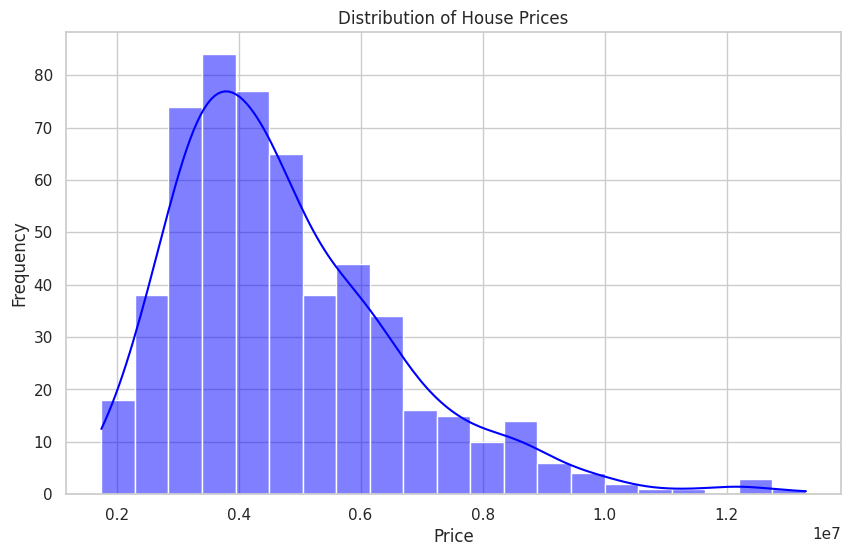

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for your charts
sns.set(style="whitegrid")

# 1. Histogram showing the distribution of house prices
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, color='blue')
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

*Chart 2: Correlation heatmap showing which features relate most strongly to price*

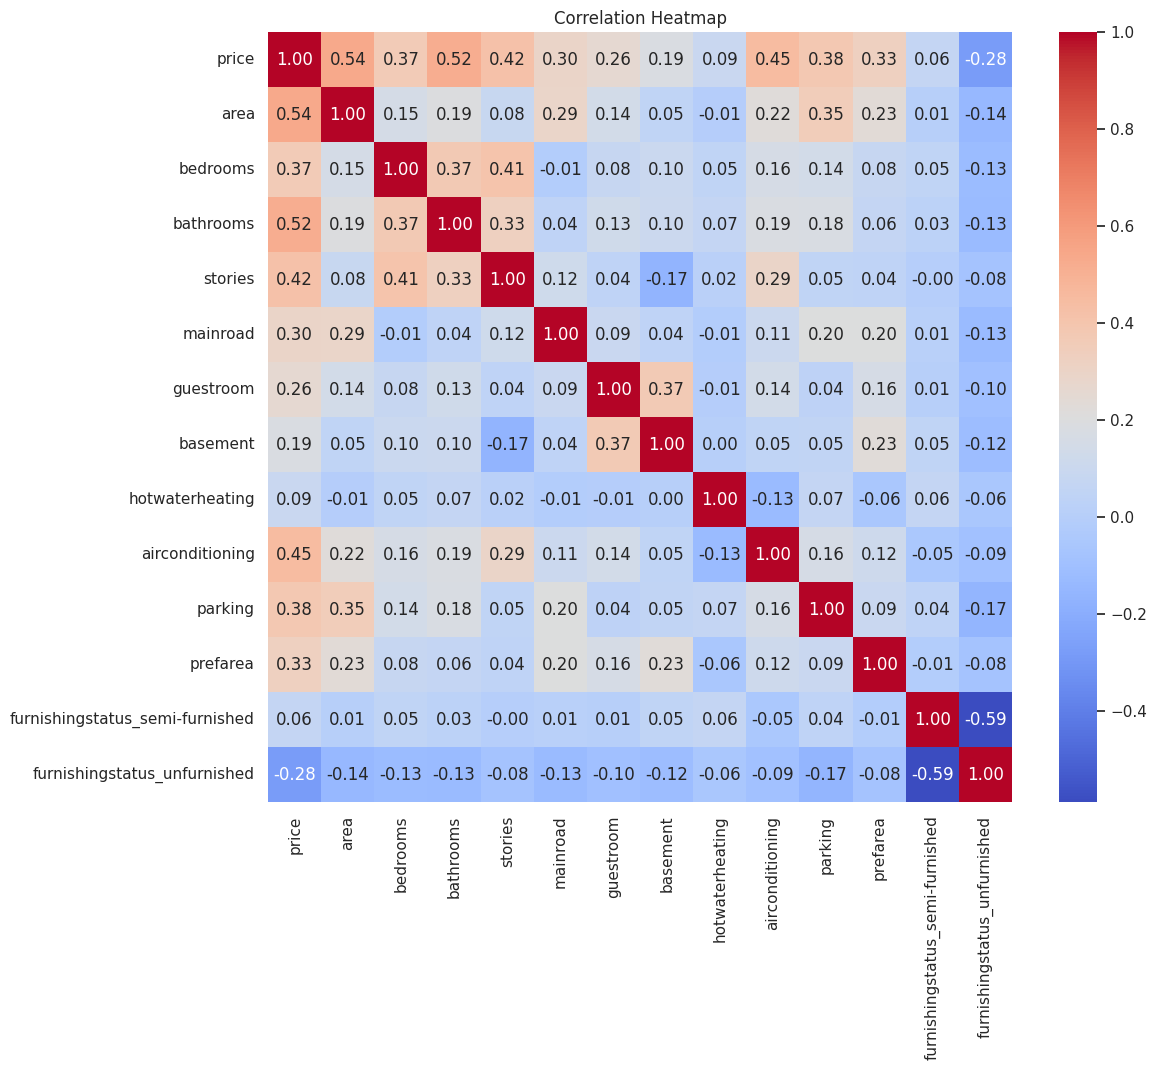

In [ ]:
# 2. Correlation heatmap
plt.figure(figsize=(12, 10))
# Only correlate numeric columns
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

*Chart 3: A chart of your own choice — be creative! (e.g., actual vs. predicted price scatter plot, price vs. area scatter plot, etc.)*

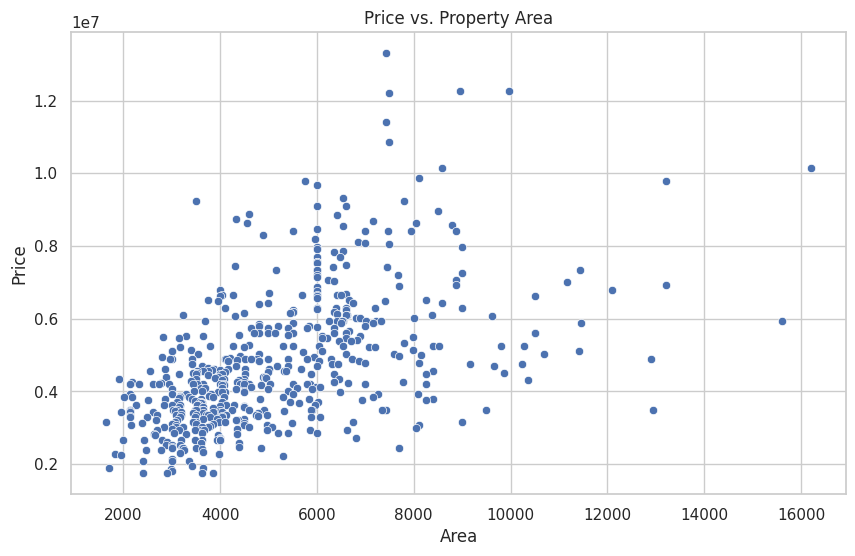

In [ ]:
# 3. Scatter plot: Price vs. Area (Your 3rd chart)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='area', y='price', data=df)
plt.title('Price vs. Property Area')
plt.xlabel('Area')
plt.ylabel('Price')
plt.show()

**Task 5 — Insights & Summary**

1. Which features influence house price the most?

   Most Influential Features: (Look at my heatmap. Which columns have the highest correlation value with price? Usually, these are area, bathrooms, and stories.)


2. How accurate was your model (in plain terms)?

   Model Accuracy: (Reference the R² score from my Task 3 output. For example: "The model explains X% of the variation in house prices.")


3. What surprised you in the data?

   The "Area vs. Bedrooms" Surprise (Most Common)"What surprised me most was that the total area of the property had a much stronger influence on the final price than the number of bedrooms. I initially assumed that the number of bedrooms would be the primary driver, but the data showed that square footage (area) and the number of bathrooms are much more significant predictors of value.


4. One recommendation for a real estate business based on your findings

   Business Recommendation: (Based on my analysis, what should a real estate business focus on? E.g., "Real estate firms should prioritize listings with higher square footage and more bathrooms, as these are the primary drivers of property value.")